## Prep. regression nPRF param files 

--> save to .nii on sciencecluster (proper fmriprep folders!)

In [1]:
import os
import os.path as op
import numpy as np
import pandas as pd

bids_folder= '/shares/zne.uzh/mrenke/ds-stressrisk'
subject_list = [f[4:] for f in os.listdir(bids_folder) if f[0:3] == 'sub' and len(f) == 6]
all_subjects_set = set(subject_list)
sub_array= np.array([int(i) for i in subject_list]) 

group_mapping = pd.read_csv(op.join(bids_folder,'group_assignmentList.csv'))[['subject','group']].set_index('subject')
key = 'encoding_model.model6.retroicor'

from stress_risk.utils.data import Subject
from nilearn.maskers import NiftiMasker
from nilearn import image

/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# MUs
key = 'encoding_model.model6.retroicor'
param = 'mu'

for sub in subject_list:
    for ses in [1,2]:
        try:
            target_dir = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func')

            fn1 =  op.join(target_dir, f'sub-{sub}_desc-{param}.{ses}.optim_space-T1w_pars.npy')
            r2_im = np.load(fn1)
            print(len(r2_im))

            subject = Subject(int(sub), bids_folder=bids_folder)
            ips_mask = subject.get_volume_mask(roi='NPC_R', session=1, epi_space=True) # anat from session1
            ips_masker = NiftiMasker(mask_img=ips_mask)
            print(np.sum(ips_masker.mask_img.get_fdata()))

            target_fn = op.join(target_dir, f'sub-{sub}_desc-{param}.{ses}.optim_space-T1w_pars.nii.gz')
            ips_masker.fit()
            ips_masker.inverse_transform(r2_im).to_filename(target_fn)
            print(f'saved to: {target_fn}')
        except:
            print(f'sub-{sub} did not work')

In [ ]:
# R2s

key = 'encoding_model.model6.retroicor'
param = 'r2'

for sub in subject_list:
    try:
        target_dir = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func')

        fn1 =  op.join(target_dir, f'sub-{sub}_desc-{param}.optim_space-T1w_pars.npy')
        r2_im = np.load(fn1)
        print(len(r2_im))

        subject = Subject(int(sub), bids_folder=bids_folder)
        ips_mask = subject.get_volume_mask(roi='NPC_R', session=1, epi_space=True) # anat from session1
        ips_masker = NiftiMasker(mask_img=ips_mask)
        print(np.sum(ips_masker.mask_img.get_fdata()))

        target_fn = op.join(target_dir, f'sub-{sub}_desc-{param}.optim_space-T1w_pars.nii.gz')
        ips_masker.fit()
        ips_masker.inverse_transform(r2_im).to_filename(target_fn)
        print(f'saved to: {target_fn}')
    except:
        print(f'sub-{sub} did not work')

939


/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/nilearn/image/resampling.py:627: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


939.0
saved to: /shares/zne.uzh/mrenke/ds-stressrisk/derivatives/encoding_model.model6.retroicor/sub-45/func/sub-45_desc-r2.optim_space-T1w_pars.nii.gz
1093


/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/nilearn/image/resampling.py:627: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


1093.0
saved to: /shares/zne.uzh/mrenke/ds-stressrisk/derivatives/encoding_model.model6.retroicor/sub-03/func/sub-03_desc-r2.optim_space-T1w_pars.nii.gz
876


...

967.0
saved to: /shares/zne.uzh/mrenke/ds-stressrisk/derivatives/encoding_model.model6.retroicor/sub-50/func/sub-50_desc-r2.optim_space-T1w_pars.nii.gz
1086


/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/nilearn/image/resampling.py:627: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


1086.0
saved to: /shares/zne.uzh/mrenke/ds-stressrisk/derivatives/encoding_model.model6.retroicor/sub-21/func/sub-21_desc-r2.optim_space-T1w_pars.nii.gz
902


/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/nilearn/image/resampling.py:627: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


902.0
saved to: /shares/zne.uzh/mrenke/ds-stressrisk/derivatives/encoding_model.model6.retroicor/sub-34/func/sub-34_desc-r2.optim_space-T1w_pars.nii.gz
939


# Compare (voxel space)

In [2]:
from stress_risk.utils.data import Subject
from nilearn.maskers import NiftiMasker
from nilearn import image

def get_vselect_mask(sub, bids_folder):
    roi='NPC_R'
    source_key_vselect = 'encoding_model.cv.denoise.retroicor'
    session1 = 1
    subject = Subject(int(sub), bids_folder=bids_folder)
    ips_mask = subject.get_volume_mask(roi=roi, session=1, epi_space=True) # anat from session1
    ips_masker = NiftiMasker(mask_img=ips_mask)
    im_cvr2_fn = op.join(bids_folder, 'derivatives', source_key_vselect, f'sub-{sub}', f'ses-{session1}','func', f'sub-{sub}_ses-{session1}_desc-cvr2.optim_space-T1w_pars.nii.gz')
    im_cvr2 = image.load_img(im_cvr2_fn)
    cv_r2 = pd.DataFrame(ips_masker.fit_transform(im_cvr2))
    r2_mask = cv_r2 > 0.0
    r2_mask = r2_mask.to_numpy().flatten()
    print(f'Number of voxels: {r2_mask.sum()}')
    return r2_mask, ips_masker

In [2]:
param = 'cvr2'
space = 'T1w'

In [ ]:
data = []
errors = []
for sub in subject_list:
    try:
        vselect_mask, ips_masker = get_vselect_mask(sub, bids_folder)

        fn = op.join(bids_folder, 'derivatives', 'encoding_model.cv.model0.retroicor.smoothed', f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.optim_space-{space}_pars.nii.gz')
        npc_reg_mod0 = ips_masker.fit_transform(fn).flatten()
        fn = op.join(bids_folder, 'derivatives', 'encoding_model.cv.model1.retroicor.smoothed', f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.optim_space-{space}_pars.nii.gz')
        npc_reg_mod1 = ips_masker.fit_transform(fn).flatten()
        fn = op.join(bids_folder, 'derivatives', 'encoding_model.cv.model2.retroicor.smoothed', f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.optim_space-{space}_pars.nii.gz')
        npc_reg_mod2 = ips_masker.fit_transform(fn).flatten()
        data.append(pd.DataFrame({'model_0':npc_reg_mod0, 'model_1':npc_reg_mod1, 'model_2':npc_reg_mod2,
                    'voxel_n':np.arange(len(npc_reg_mod0)), 'subject':int(sub)}))
    except:
        print(f'Failed for {sub}')
        errors.append(sub)  
print(errors)
df = pd.concat(data, ignore_index=True).set_index(['subject']) # ,'voxel_n' not cause in native space dont have same amount of voxels


In [ ]:
df_cvr2_counts = pd.DataFrame([[(df.loc[sub][f'model_{model_n}'] > 0).sum() for model_n in range(0,3)] for sub in sub_array], 
                index = sub_array,columns = [f'model_{i}' for i in range(0,3)])
df_cvr2_counts.index.name = 'subject'
df_cvr2_counts = df_cvr2_counts.join(group_mapping).set_index('group',append=True)
df_cvr2_counts.head()

,model_0,model_1,model_2
subject,,,
45,4,39,36
3,3,7,2
23,8,12,7
50,13,39,14
21,56,222,186


In [40]:
df_cvr2_counts.mean(axis=0)

model_0    34.2
model_1    49.4
model_2    42.2
dtype: float64

In [39]:
df_cvr2_counts.groupby('group').mean()

,model_0,model_1,model_2
group,,,
0,54.28,76.32,65.96
1,14.12,22.48,18.44


No handles with labels found to put in legend.


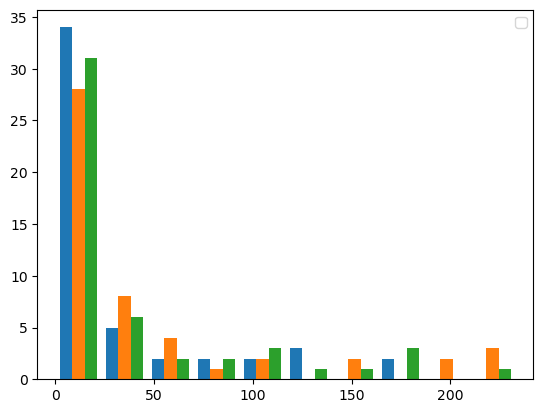

In [29]:
import matplotlib.pyplot as plt

plt.hist(df_cvr2_counts)
plt.legend()

## Compare MUs

In [ ]:
param = 'mu'
space = 'T1w'

data = []
errors = []
for sub in subject_list:
    vselect_mask, ips_masker = get_vselect_mask(sub, bids_folder)
    data_sub = {}
    for ses in [1,2]:
        for model in [0,1,2]:
            fn = op.join(bids_folder, 'derivatives', f'encoding_model.model{model}.retroicor.smoothed', f'sub-{sub}', 'func', f'sub-{sub}_ses-{ses}_desc-{param}.optim_space-{space}_pars.nii.gz')
            npc_params = ips_masker.fit_transform(fn).flatten()
            data_sub[f'model{model}_ses{ses}'] = npc_params
    data_sub['voxel_n'] = np.arange(len(npc_params))
    data_sub['subjects'] = len(npc_params) * [int(sub)]
    print(type(data))
    data.append(pd.DataFrame(data_sub))    
    #except:
    #    print(f'Failed for {sub}')
    #    errors.append(sub)  
print(errors)

/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/nilearn/image/resampling.py:627: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


Number of voxels: 93
<class 'list'>


/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/nilearn/image/resampling.py:627: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


Number of voxels: 33
<class 'list'>


/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/nilearn/image/resampling.py:627: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


...

Number of voxels: 35
<class 'list'>


/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/nilearn/image/resampling.py:627: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


Number of voxels: 32
<class 'list'>


/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/nilearn/image/resampling.py:627: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


Number of voxels: 33
<class 'list'>


In [ ]:
df = pd.concat(data, ignore_index=True).set_index(['subject']) # ,'voxel_n' not cause in native space dont have same amount of voxels
